# Space Launch Data Integration: Three Datasets

**Notebook 3** - Data Merging Phase

## Purpose
Merge the three cleaned TSV files into one complete dataset for downstream analysis. Performs merge using launch ID as the primary key.

## Authors
- **Phillip Roman** - Data integration and merge
- **Team Contributors:**
  - Jillian Kunze - Rocket parameters
  - Innocent Gumunyu - Launch parameters
  - Phillip Roman - Mission parameters
  - Ryan Peters - GitHub Management

## Workflow Position
1. Data Collection → Raw launch data collected via API
2. Data Cleaning → Extract parameters from raw data:
   - 2a. Extract rocket parameters
   - 2b. Extract launch parameters
   - 2c. Extract mission parameters
3. **This Notebook** → Merge all cleaned datasets

## Key Features
- **Flexible Data Loading:** Automatically downloads data from GitHub if the local file isn't found (ensures the code works in Google Colab).
- **Automated Directory Creation:** Checks if the output folder exists and creates it if necessary to prevent file saving errors.

## Merge Strategy
- **Primary key:** Launch ID column (standardized across all datasets)
- **Merge type:** Outer join to preserve all records
- **Two-step merge:** first Rocket + Launch, then add Mission data

## Input Files
- `clean_rocket_data.tsv` - 15 rocket attributes
- `clean_launch_data.tsv` - 16 launch attributes
- `clean_mission_data.tsv` - 10 mission attributes

## Output
- `merged_data.tsv` - Complete dataset with 39 attributes ready for analysis

## Import Required Libraries

In [25]:
import pandas as pd
import requests
import io
import os

## Load Cleaned Data Files

This cell uses a **hybrid loading function** to import the three cleaned datasets.

**Workflow:**
1.  **Local Check:** It looks for files in `../data/cleaned data/` first.
2.  **Cloud Fallback:** If running in a new environment (like Google Colab) where local files are missing, it automatically streams the TSV files directly from the project's GitHub repository.

In [26]:
# primary - local path
local_dir = os.path.join("..", "data", "cleaned data")

# backup for cloud/colab
github_base_url = "https://github.com/Rybus07/space-legends-data/raw/main/data/cleaned%20data"

def load_dataset(filename):
    """Attempts to load a TSV locally; falls back to GitHub if missing."""
    local_path = os.path.join(local_dir, filename)

    if os.path.exists(local_path):
        print(f"Loading locally: {filename}...")
        return pd.read_csv(local_path, sep='\t')

    # fallback to Github
    else:
        print(f"Local file not found. Streaming {filename} from GitHub...")
        url = f"{github_base_url}/{filename}"
        response = requests.get(url)

        if response.status_code == 200:
            return pd.read_csv(io.BytesIO(response.content), sep='\t')
        else:
            raise FileNotFoundError(f"Failed to load {filename} from both local path and GitHub.")

# the file loading
try:
    rocket_df = load_dataset("clean_rocket_data.tsv")
    launch_df = load_dataset("clean_launch_data.tsv")
    mission_df = load_dataset("clean_mission_data.tsv")

    print("\nSUCCESS: All datasets loaded.")
    print("Rocket data:", rocket_df.shape)
    print("Launch data:", launch_df.shape)
    print("Mission data:", mission_df.shape)

except Exception as e:
    print(f"\nCRITICAL ERROR: {e}")

Local file not found. Streaming clean_rocket_data.tsv from GitHub...
Local file not found. Streaming clean_launch_data.tsv from GitHub...
Local file not found. Streaming clean_mission_data.tsv from GitHub...

SUCCESS: All datasets loaded.
Rocket data: (7336, 15)
Launch data: (7336, 16)
Mission data: (7336, 10)


## Check Column Names

Check which columns are in each file and confirm ID columns match.

In [27]:
print("Rocket columns:", list(rocket_df.columns))
print("Launch columns:", list(launch_df.columns))
print("Mission columns:", list(mission_df.columns))

Rocket columns: ['ID', 'Rocket_name', 'Manufacturer_name', 'Manufacturer_country', 'Manufacturer_company_type', 'Reusability', 'Min_no_stages', 'Max_no_stages', 'Rocket_length', 'Rocket_diameter', 'Launch_cost', 'Liftoff_mass_tons', 'Liftoff_thrust_kN', 'Rocket_apogee', 'Payload_mass']
Launch columns: ['ID', 'Launch Name', 'Launch Date', 'Country', 'Location Name', 'Latitude', 'Longitude', 'Fail Reason', 'Location Launch Attempt Count', 'Location Launch Attempt Count Year', 'Pad', 'Pad Launch Attempt Count', 'Status', 'Timeline Stages', 'Window Start', 'Window End']
Mission columns: ['launch_id', 'mission_id', 'mission_name', 'mission_type', 'mission_description', 'orbit_name', 'orbit_abbrev', 'program_name', 'lsp_name', 'lsp_type']


## Check ID Column Names

Make sure ID columns match before merging - need to rename if different.

In [28]:
print("Rocket ID column:", rocket_df.columns[0])
print("Launch ID column:", launch_df.columns[0])
print("Mission ID column:", mission_df.columns[0])

Rocket ID column: ID
Launch ID column: ID
Mission ID column: launch_id


## Fix Mission ID Column Name

Mission file uses 'launch_id' but the other two use 'ID' - rename it to match.

In [29]:
mission_df.rename(columns={'launch_id': 'ID'}, inplace=True)

# recheck ID column names
print("Rocket ID column:", rocket_df.columns[0])
print("Launch ID column:", launch_df.columns[0])
print("Mission ID column:", mission_df.columns[0])

Rocket ID column: ID
Launch ID column: ID
Mission ID column: ID


## Merge Rocket and Launch Data

Combine rocket and launch DataFrames on ID column using outer join.

In [30]:
rocket_and_launch = pd.merge(rocket_df, launch_df, on='ID', how='outer')
print(f"After merging Rocket + Launch: {rocket_and_launch.shape}")

# visual check
print(rocket_and_launch.head())
print("\nTotal columns:", len(rocket_and_launch.columns))

After merging Rocket + Launch: (7336, 30)
                                     ID     Rocket_name  \
0  000fbb81-80c8-4095-a811-aa561ce9ed3c  Delta IV Heavy   
1  00190507-4918-491a-aa73-0e151775fada   Long March 2D   
2  002ca252-2ad6-4e8e-b899-0564c86b5fe9       Tsiklon-2   
3  0041d2ac-62cb-416f-b67a-cd0277f1cfe2        Soyuz-U2   
4  00441721-5019-4c49-aa85-e38aad2d3937     Proton-K/DM   

                                   Manufacturer_name  \
0                                             Boeing   
1  China Aerospace Science and Technology Corpora...   
2                             Yuzhnoye Design Bureau   
3                                                NaN   
4  Khrunichev State Research and Production Space...   

       Manufacturer_country Manufacturer_company_type  Reusability  \
0  United States of America                Commercial        False   
1                     China                Government        False   
2                   Ukraine                Commercial   

## Second Merge: Add Mission Data

Merge mission DataFrame into the combined rocket+launch data.

In [31]:
final_df = pd.merge(rocket_and_launch, mission_df, on='ID', how='outer')
print(f"Final merged data: {final_df.shape}")

# visual recheck
print(final_df.head(3))

Final merged data: (7336, 39)
                                     ID     Rocket_name  \
0  000fbb81-80c8-4095-a811-aa561ce9ed3c  Delta IV Heavy   
1  00190507-4918-491a-aa73-0e151775fada   Long March 2D   
2  002ca252-2ad6-4e8e-b899-0564c86b5fe9       Tsiklon-2   

                                   Manufacturer_name  \
0                                             Boeing   
1  China Aerospace Science and Technology Corpora...   
2                             Yuzhnoye Design Bureau   

       Manufacturer_country Manufacturer_company_type  Reusability  \
0  United States of America                Commercial        False   
1                     China                Government        False   
2                   Ukraine                Commercial        False   

   Min_no_stages  Max_no_stages  Rocket_length  Rocket_diameter  ...  \
0            2.0            2.0           72.0             5.00  ...   
1            1.0            2.0           38.3             3.35  ...   
2          

## Save Merged Dataset

This cell exports the final combined dataset to a TSV file.

**Features:**
- **Automatic Directory Creation:** Checks if the target folder (`../data/cleaned data/`) exists and creates it if missing, preventing errors in new environments.
- **TSV Format:** Saves as Tab-Separated Values to safely handle text fields containing commas.
- **Validation:** Prints the final dataframe shape and file size to confirm the export was successful.

In [32]:
output_filename = 'merged_data.tsv'
save_path = os.path.join("..", "data", "cleaned data", output_filename)

print(f"Attempting to save data to: {save_path}")

# check if directory exists
folder_path = os.path.dirname(save_path)
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created missing directory structure: {folder_path}")

# saves file
try:
    final_df.to_csv(save_path, sep='\t', index=False)
    print(f"Success! Data saved to: {save_path}")
    print(f"Final shape: {final_df.shape}")
    print(f"File size: {os.path.getsize(save_path) / (1024 * 1024):.2f} MB") # file size in MB
except Exception as e:
    print(f"Error saving file: {e}")

Attempting to save data to: ../data/cleaned data/merged_data.tsv
Success! Data saved to: ../data/cleaned data/merged_data.tsv
Final shape: (7336, 39)
File size: 4.55 MB


## Interact with the Merged Dataset

In this final section, we explore the merged dataset to understand its structure and completeness. The following cells provide options to visualize missing values (nulls) and gain a broad overview of the compiled rocket, launch, and mission data.

### View Dataset Information

In [33]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7336 entries, 0 to 7335
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  7336 non-null   object 
 1   Rocket_name                         7336 non-null   object 
 2   Manufacturer_name                   6677 non-null   object 
 3   Manufacturer_country                6677 non-null   object 
 4   Manufacturer_company_type           6677 non-null   object 
 5   Reusability                         7336 non-null   bool   
 6   Min_no_stages                       5914 non-null   float64
 7   Max_no_stages                       5914 non-null   float64
 8   Rocket_length                       5800 non-null   float64
 9   Rocket_diameter                     5799 non-null   float64
 10  Launch_cost                         2101 non-null   float64
 11  Liftoff_mass_tons                   5702 no

### View the tail of the dataframe

Shows the five most recent launches in the dataset

In [34]:
final_df.tail()

,ID,Rocket_name,Manufacturer_name,Manufacturer_country,Manufacturer_company_type,Reusability,Min_no_stages,Max_no_stages,Rocket_length,Rocket_diameter,...,Window End,mission_id,mission_name,mission_type,mission_description,orbit_name,orbit_abbrev,program_name,lsp_name,lsp_type
7331,ffc148dc-76cc-4c5e-95b6-c2c78d6f0ba6,Falcon 9 Block 5,SpaceX,United States of America,Commercial,True,1.0,2.0,70.0,3.65,...,2024-11-27T06:30:00Z,7006.0,Starlink Group 6-76,Communications,A batch of 24 satellites for the Starlink mega...,Low Earth Orbit,LEO,Starlink,SpaceX,Commercial
7332,ffc553f5-ff40-49fb-a2e0-b49cc788c7c2,Soyuz U,Progress Rocket Space Center,Russia,Commercial,False,2.0,3.0,51.1,2.95,...,1984-05-11T13:00:00Z,4032.0,Zenit-6U 95,Government/Top Secret,Optical film-return reconnaissance satellite,Low Earth Orbit,LEO,NaN,Soviet Space Program,Government
7333,ffcada79-ba45-4753-b55c-ca537c48c31e,Proton-K/Briz-M,Khrunichev State Research and Production Space...,Russia,Government,False,4.0,4.0,57.0,4.15,...,1999-07-05T13:32:00Z,5318.0,Raduga 34,Communications,Geostationary communications satellite for mil...,Geostationary Orbit,Direct-GEO,NaN,Khrunichev State Research and Production Space...,Government
7334,ffd29f94-06b4-49f7-b5f9-b21a928e6eaa,Falcon 9 Block 5,SpaceX,United States of America,Commercial,True,1.0,2.0,70.0,3.65,...,2024-02-20T22:11:00Z,6634.0,HTS-113BT (Merah Putih 2),Communications,HTS-113BT is a new High Throughput Satellite t...,Geostationary Transfer Orbit,GTO,NaN,SpaceX,Commercial
7335,ffe1ba5c-ef04-4cc3-8746-f9abd7da2211,Kosmos 11K65,Strategic Rocket Forces,Russia,Government,False,2.0,2.0,26.0,2.40,...,1968-08-27T11:29:00Z,2234.0,Strela-2 5,Communications,The Strela-2 satellites were prototypes of the...,Low Earth Orbit,LEO,NaN,Soviet Space Program,Government


### Check for Missing Values

See which columns have missing data after merging

In [35]:
missing = final_df.isnull().sum()
print("Columns with missing data:")
print(missing[missing > 0])  # shows just the ones with nulls

Columns with missing data:
Manufacturer_name             659
Manufacturer_country          659
Manufacturer_company_type     659
Min_no_stages                1422
Max_no_stages                1422
Rocket_length                1536
Rocket_diameter              1537
Launch_cost                  5235
Liftoff_mass_tons            1634
Liftoff_thrust_kN            3176
Rocket_apogee                5988
Payload_mass                 2107
Country                        47
Fail Reason                  7218
mission_id                    517
mission_name                  517
mission_type                  543
mission_description           517
orbit_name                    530
orbit_abbrev                  540
program_name                 5863
dtype: int64


### Dataset Table: Dimensions and File Sizes

In [36]:
summary = {
    'File': ['Merged Dataset', 'Rocket Parameters', 'Launch Parameters', 'Mission Parameters'],
    'Rows': [7336, 7336, 7336, 7336],
    'Columns': [39, 15, 16, 10],
    'File Size': ['4.6 MB', '1 MB', '2.1 MB', '2 MB']
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_markdown(index=False))

| File               |   Rows |   Columns | File Size   |
|:-------------------|-------:|----------:|:------------|
| Merged Dataset     |   7336 |        39 | 4.6 MB      |
| Rocket Parameters  |   7336 |        15 | 1 MB        |
| Launch Parameters  |   7336 |        16 | 2.1 MB      |
| Mission Parameters |   7336 |        10 | 2 MB        |


### Missing Data Chart

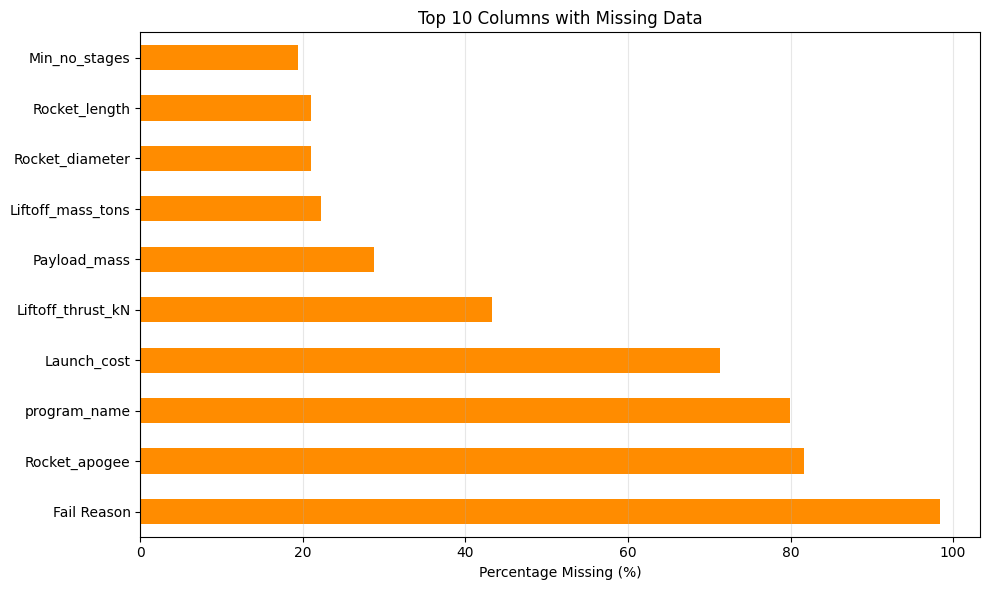

In [37]:
import matplotlib.pyplot as plt

# to store visuals
os.makedirs('figures', exist_ok=True)

# missing percentages
missing_pct = (final_df.isnull().sum() / len(final_df) * 100).sort_values(ascending=False).head(10)

# bar chart
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Top 10 Columns with Missing Data')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()


plt.savefig('figures/data_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

### Historical Launch Timeline Plot

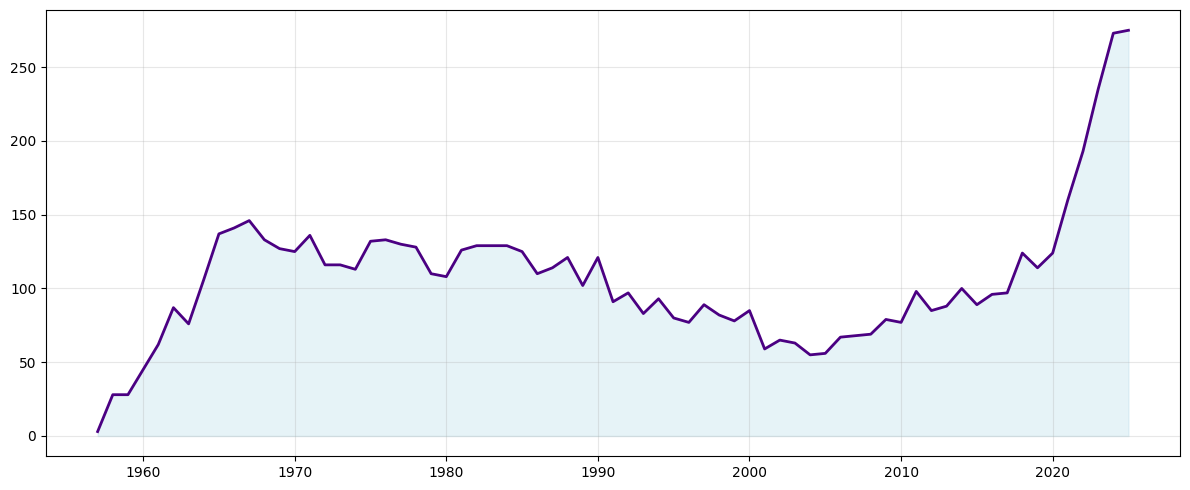

In [38]:
import matplotlib.pyplot as plt

# extract year from launch date
final_df['year'] = pd.to_datetime(final_df['Launch Date']).dt.year

# launches per year
yearly_counts = final_df['year'].value_counts().sort_index()

# line plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly_counts.index, yearly_counts.values, linewidth=2, color='indigo')
ax.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3, color='lightblue')
##ax.set_xlabel('Year')
#ax.set_ylabel('Number of Launches')
#ax.set_title('Complete historical coverage from Sputnik (1957) through 2025')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/temporal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical Breakdown Table

In [39]:

breakdown = pd.DataFrame({
    'Launch Status': final_df['Status'].value_counts(),
    'Top Mission Types': final_df['mission_type'].value_counts().head(5),
    'Top Rocket Families': final_df['Rocket_name'].value_counts().head(5)
})

print(" Dataset Categorical Breakdown:\n")
print("Launch Status Breakdown:")
print(final_df['Status'].value_counts().to_markdown())
print("\nTop 5 Mission Types:")
print(final_df['mission_type'].value_counts().head(5).to_markdown())
print("\nTop 5 Most Used Rockets:")
print(final_df['Rocket_name'].value_counts().head(5).to_markdown())

 Dataset Categorical Breakdown:

Launch Status Breakdown:
| Status                       |   count |
|:-----------------------------|--------:|
| Launch Successful            |    6789 |
| Launch Failure               |     513 |
| Launch was a Partial Failure |      34 |

Top 5 Mission Types:
| mission_type          |   count |
|:----------------------|--------:|
| Government/Top Secret |    2253 |
| Communications        |    1570 |
| Earth Science         |     936 |
| Navigation            |     407 |
| Test Flight           |     342 |

Top 5 Most Used Rockets:
| Rocket_name        |   count |
|:-------------------|--------:|
| Soyuz U            |     714 |
| Falcon 9 Block 5   |     503 |
| Kosmos-3M (11K65M) |     445 |
| Voskhod            |     299 |
| Molniya-M 2BL      |     272 |
